In [237]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import FancyArrowPatch

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/XXZ/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


0.0 [10000. 10000.  6000.  3000.   571.] [0.49060047 0.5035435  0.51747062 0.52581377 0.52912588]
0.01 [10000. 10000.  6000.  3000.   581.] [0.5112074  0.52232887 0.5279174  0.5298145  0.53049437]
0.02 [10000. 10000.  6000.  3000.   560.] [0.51811542 0.52648191 0.52954276 0.53032381 0.53060721]
0.03 [10000. 10000.  6000.  3000.   604.] [0.51708442 0.52682216 0.52973651 0.53043871 0.53072306]
0.04 [10000. 10000.  6000.  3000.   601.] [0.51016844 0.52383996 0.52908874 0.53028485 0.53062501]
0.05 [10000. 10000.  6000.  3000.   576.] [0.49892482 0.5166608  0.52748968 0.52998071 0.53057292]
0.06 [10000. 10000.  6000.  3000.   576.] [0.48567915 0.504023   0.52387352 0.52923498 0.53040174]
0.07 [10000. 10000.  6000.  3000.   585.] [0.46971258 0.48807818 0.51530802 0.52731765 0.5299781 ]
0.08 [10000. 10000.  6000.  3000.   594.] [0.45240716 0.47043842 0.50134183 0.52268254 0.52906602]
0.09 [10000. 10000.  6000.  3000.   617.] [0.43787258 0.45388508 0.48392114 0.5127175  0.52684837]
0.1 [10000.

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


0.37 [10000. 10000.  6000.  3000.   585.] [0.38070561 0.38198494 0.38476602 0.38531657 0.38673081]
0.38 [10000. 10000.  6000.  3000.   600.] [0.3807056  0.38198467 0.38476598 0.38531579 0.38672782]
0.39 [10000. 10000.  6000.  3000.   602.] [0.3807056  0.38198453 0.38476596 0.38531538 0.38672608]
0.4 [10000. 10000.  6000.  3000.   583.] [0.38070559 0.38198445 0.38476594 0.38531515 0.3867251 ]


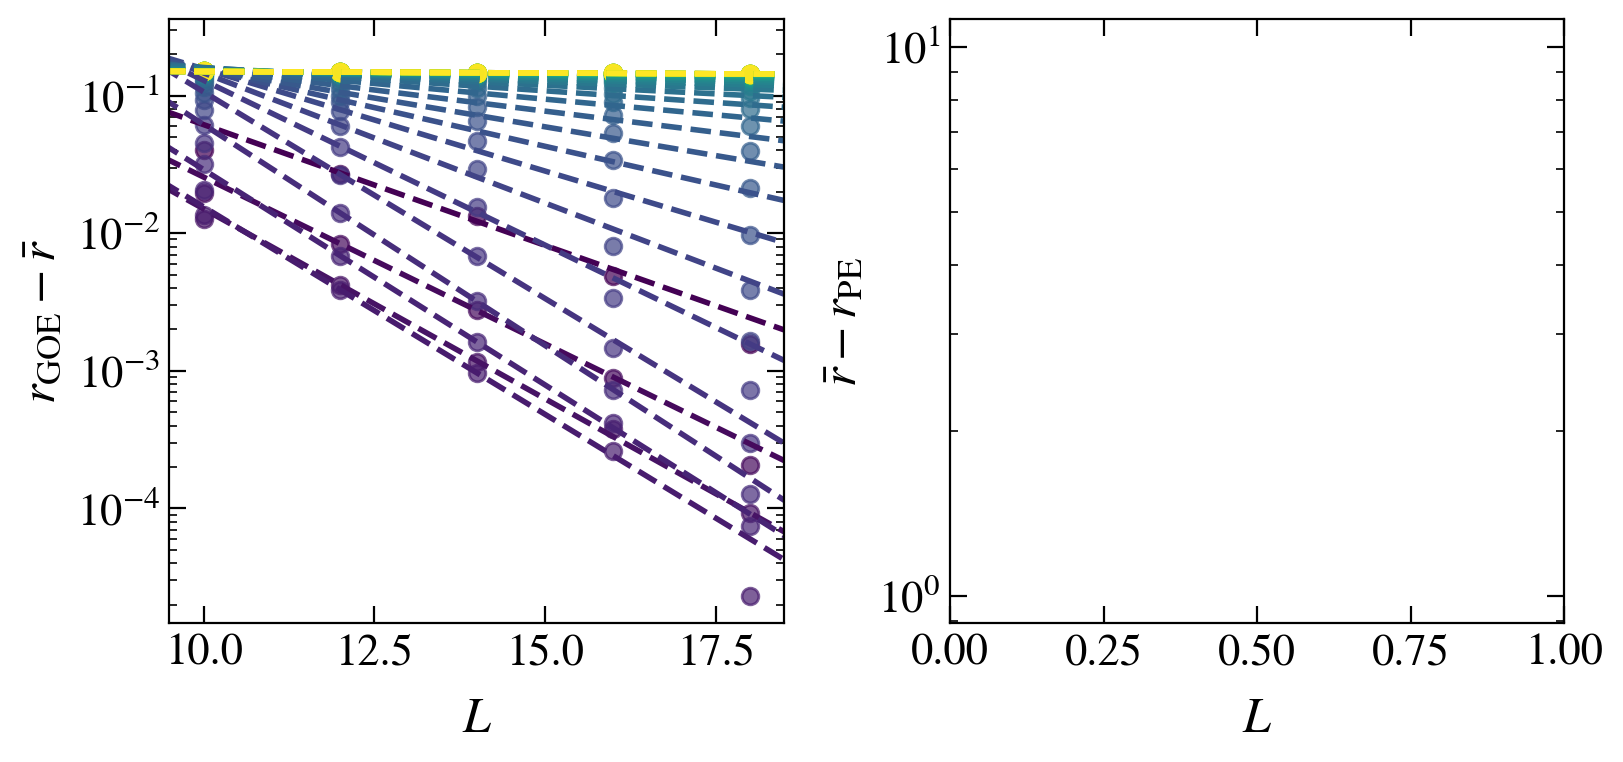

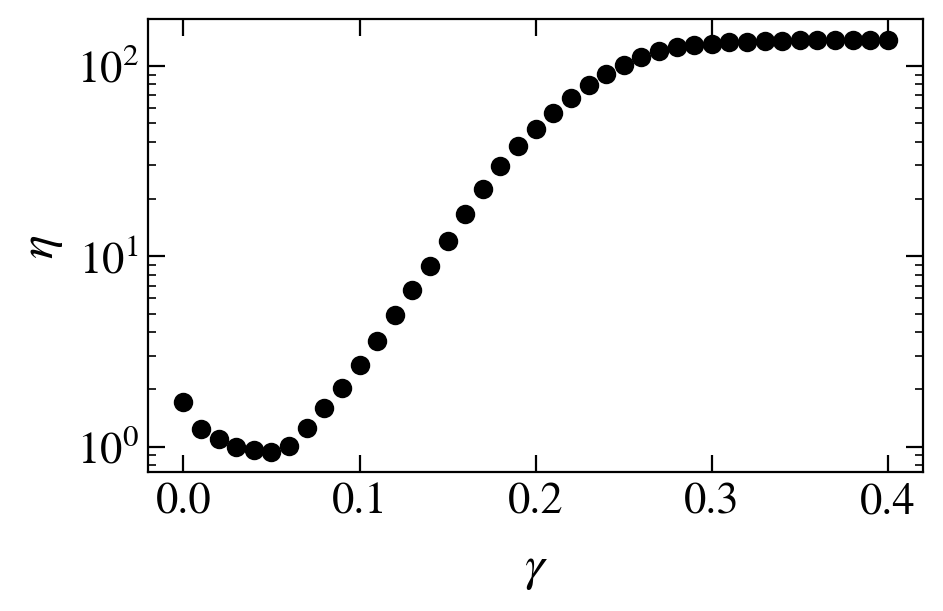

In [270]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(10, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(9,4), dpi = 200, sharex=False, sharey=False)
fig2, ax = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200, sharex=False, sharey=False)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

for iig, wx_vals in enumerate([np.arange(0.0, 0.41, 0.01 if BC else 0.02)]):
# gamma_vals = np.arange(0.5, 2.01, 0.1)
    dim = int( binom(L, L//2) )

    norm = matplotlib.colors.Normalize(
            vmin=min(wx_vals),
            vmax=max(wx_vals))
    s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
    s_m.set_array([])

    etas = []
    for ibsifusdf, wx in enumerate(wx_vals):
        col = s_m.to_rgba(wx)
        
        gap_ratio = np.zeros(sizes.shape)
        realis = np.zeros(sizes.shape)
        # ------------------------------------------------------------ ROZENZWEIG-PORTER
        for iiL, L in enumerate(sizes):
            dim = int( binom(L, L//2) )
            counter = 0
            r = 0#np.zeros((45))
            
            name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energy_density'))
                    DOS = np.array(file.get('DOS'))
                    idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                    
                    gap_ratio[iiL] = np.mean(np.array(file.get('gap_ratios')))
                    
                    realis[iiL] = np.array(file.get('realisations'))
            else:
                print(name)
        
        print(wx, realis, gap_ratio)
        # yy = 1 - (gap_ratio - (2*np.log(2)-1) ) / (0.5307 - (2*np.log(2)-1))
        yy = 0.5307 - gap_ratio if iig == 0 else gap_ratio - (2*np.log(2) - 1)
        # yy = (4 - 2*np.sqrt(3)) - gap_ratio if iig == 0 else gap_ratio - (2*np.log(2) - 1)
        # yy = gap_ratio
        yy = np.abs(yy)
        # print(gx, sizes, yy)
        parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                        xdata = sizes[-4:],
                        ydata = yy[-4:],
                        full_output=True, maxfev=10000)
        A = parsolo[0]
        eta_fit = 1 / parsolo[1]
        if eta_fit > 1e6:
            eta_fit = np.nan
        etas.append(eta_fit)
        # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
        z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
        axis[iig].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
        axis[iig].scatter(sizes, yy, color=col, alpha=0.7)
    
    etas = np.array(etas)
    ax.scatter(wx_vals, np.abs(etas), color='red' if iig else 'k', marker='s' if iig else 'o', facecolor='None' if iig else 'k')
    
    
    axis[iig].set_xlim(min(sizes)-0.5, max(sizes)+0.5)
    

# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$r_{\rm GOE}-\bar{r}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(ax, ylabel=r"$\eta$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


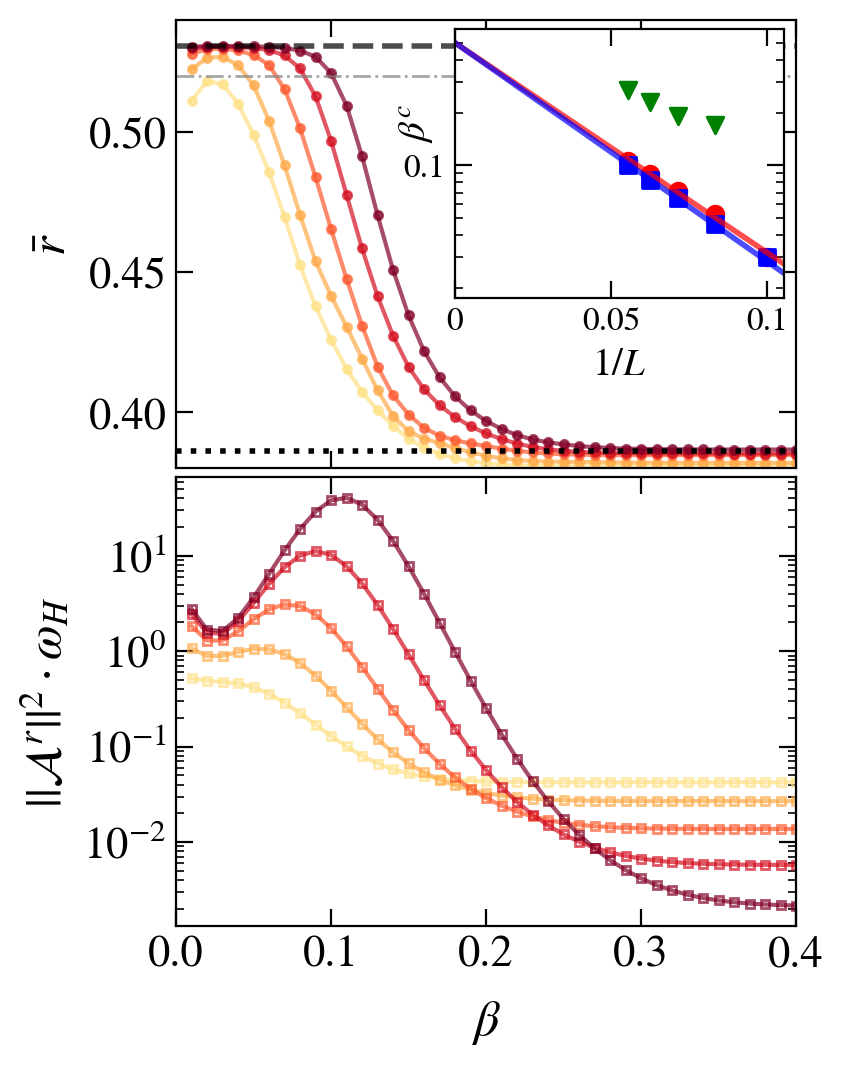

In [348]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(10, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5

dw = 0.01 if BC else 0.02
wx_vals = np.arange(dw, 0.41, dw)



norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


agp_max = np.zeros(sizes.shape)
r_drift = np.zeros(sizes.shape)
AGPs = []
for iiL, L in enumerate(sizes):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    gap_ratio = np.zeros(wx_vals.shape)
    agp = np.zeros(wx_vals.shape)
    realis = np.zeros(wx_vals.shape)
    for iiw, wx in enumerate(wx_vals):
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                wH = np.array(file.get('wH'))[-2]
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios')))#[dim//4 : -dim//4])
                # agp[iiL] = np.array(file.get('SUSC_R'))[-2] * wH
                agp[iiw] = np.array(file.get('TYP_SUSC_R'))[-2] * wH
                
                realis[iiw] = np.array(file.get('realisations'))
        else:
            print(name)
    
    axis[0].plot(wx_vals, gap_ratio, color=col, marker='o', alpha=0.7, markersize=3)
    axis[1].plot(wx_vals, agp, color=col, markerfacecolor='None', marker='s', alpha=0.7, markersize=3)

    xx = wx_vals[wx_vals > 0.02]
    yy = agp[wx_vals > 0.02]
    AGPs.append(yy)
    
    indices = np.arange( max([np.argmax(yy) - 5, 0]), min([np.argmax(yy) + 10,xx.size]), 1)
    x = np.linspace(xx[indices][0], xx[indices][-1], 1000)
    f = splrep(xx[indices], yy[indices], k=5, s=10)
    yy = splev(x, f)
    agp_max[iiL] = x[np.argmax(yy)]
    
    yy = gap_ratio[wx_vals > 0.02]
    idx = np.argmin(np.abs(yy - 0.52))
    indices = np.arange( max([idx - 5, 0]), min([idx + 10, xx.size]), 1)
    f = splrep(xx[indices], yy[indices], k=5, s=10)
    yy = splev(x, f)
    r_drift[iiL] = x[np.argmin(np.abs(yy - 0.52))]
    
AGPs = np.array(AGPs)
agp_cross = np.zeros( (sizes.size-1))    
for iiL, L in enumerate(sizes[1:]):
    agp_cross[iiL] = (wx_vals[wx_vals > 0.02])[np.argmin(np.abs(AGPs[iiL+1] - AGPs[iiL]))]
 
fig_help.set_plot_elements(axis[0], ylabel=r"$\bar{r}$", xlabel=r"", font_size=16, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"$||\mathcal{A}^r||^2\cdot\omega_H$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis[0].set_ylim(0.38 if BC else 0., 0.54)
axis[0].axhline(y=0.5308, ls='--', color='k', lw=2, alpha=0.7)
axis[0].axhline(y=0.52, ls='-.', color='gray', lw=1, alpha=0.7)
axis[0].axhline(y=2*np.log(2)-1, ls=':', color='k', lw=2)
axis[0].set_xlim(0, 0.4)

inset = axis[0].inset_axes([0.45, 0.38, 0.53, 0.6])
# inset.scatter(1/sizes, agp_max, marker='o', color='red')
# inset.scatter(1/sizes, r_drift, marker='s', color='blue')
inset.scatter(1/sizes[1:], agp_cross, marker='v', color='green')

def beta_c_fit(L, a, C):
    # return (np.log(2) - np.log(1/4**L * (C**2 * L + C * np.sqrt(L) * np.sqrt(4**(L+1) * a + C**2 * L)))) / (L * np.log(4))
    # return (np.log(2) - np.log(1/4**L * (C**2 * L**5 + C * np.sqrt(L**5) * np.sqrt(4**(L+1) * a + C**2 * L**5)))) / (L * np.log(4))
    # return 0.5 - C * np.exp(-a * L)
    return 0.5 * np.exp(-a / L)
    # return 0.5 + 1 / (2*L) - 1/2 * np.log(a * L) / (L * np.log(4))


LOG = 1
def plot_fit_inset(x, y, mar = 'o', col = 'red'):
    pars, pconv, fit_info, msg, _ = fit(beta_c_fit,
                        xdata = x,
                        ydata = y,
                        full_output=True, maxfev=10000)
    x_den = np.linspace(0, 1/(min(x)-1), 10000)
    # x_den = np.linspace(min(x)-1, max(x)+1, 10000)
    inset.scatter(1/x, y, marker=mar, color=col)
    inset.plot(x_den, beta_c_fit(1/x_den, *pars), color=col, ls='-', lw=2, alpha=0.7)
    # print(y, beta_c_fit(x, *pars))
    # inset.plot(x_den, )
plot_fit_inset(sizes, agp_max, mar='o', col='red')
plot_fit_inset(sizes, r_drift, mar='s', col='blue')
# inset.scatter(sizes[1:], agp_cross, marker='v', color='green')(1/sizes[1:], agp_cross, marker='v', color='green')

fig_help.set_plot_elements(inset, ylabel=r"$\beta^c$", xlabel=r"$1/L$", font_size=12, set_legend=True, xscale='linear', yscale='log')
inset.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
inset.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
inset.yaxis.set_label_coords(-0.06, 0.65)
inset.set_xlim(0, 1/(min(sizes)-0.5))
# inset.set_xlim(min(sizes)-0.5, max(sizes)+0.5)
inset.set_ylim(None, 0.6)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

## SPECTRAL FUNCTIONS

No handles with labels found to put in legend.


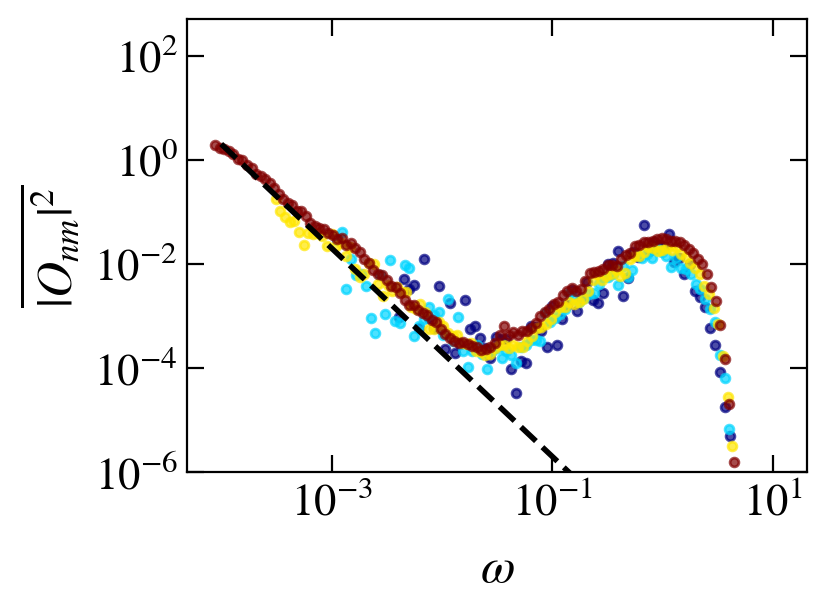

In [263]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = '../results/disorder/OBC/Spectrals_SzSz/'
hz=1

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5

wx_vals = np.arange(0.2, 8.21, 0.2)



norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])


wx = 0.18
for iiL, L in enumerate(sizes):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            DOS = np.array(file.get('DOS'))[idx]
            wH = np.array(file.get('wH'))[0]
            
            G = 1#dim**(1-2*w) * L**2
            spec_fun = np.array(file.get('spec_fun_typ'))[idx] * DOS * G
            omegas = np.array(file.get('omegas'))[1:] / G
            
            realis = np.array(file.get('realisations'))
    else:
        print(name)
    
    # axis.scatter(omegas, spec_fun, color=col, alpha=0.7, s=10)
    axis.scatter(omegas[omegas > wH], spec_fun[omegas > wH], color=col, alpha=0.7, s=10)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$\overline{|O_{nm}|^2}$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

z = np.logspace(-4, 1, 1000)
# axis.plot(z, 0.02/z, ls=':', color='k', lw=2)
axis.plot(z, 2e-8/z**2, ls='--', color='k', lw=2)

axis.set_ylim(1e-6, 5e2)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.


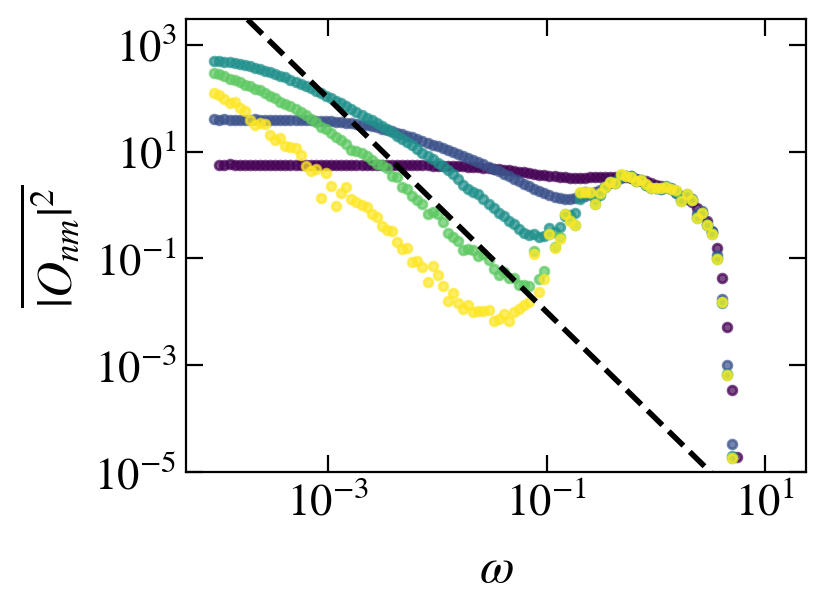

In [254]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = '../results/disorder/PBC/Spectrals_SzSz/'

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 18
eps = 0.5

wx_vals = np.arange(0.02, 0.22, 0.04)



norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])


wx = 0.04
for iiL, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            DOS = np.array(file.get('DOS'))[idx]
            wH = np.array(file.get('wH'))[0]
            
            G = 1#dim**(1-2*w) * L**2
            spec_fun = np.array(file.get('spec_fun'))[idx] * DOS * G
            omegas = np.array(file.get('omegas'))[1:] / G
            
            realis = np.array(file.get('realisations'))
    else:
        print(name)
    
    axis.scatter(omegas[omegas > wH], spec_fun[omegas > wH], color=col, alpha=0.7, s=10)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$\overline{|O_{nm}|^2}$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

z = np.logspace(-4, 1, 1000)
# axis.plot(z, 0.02/z, ls=':', color='k', lw=2)
axis.plot(z, 0.0001/z**2, ls='--', color='k', lw=2)

axis.set_ylim(1e-5, 3e3)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

24310.0

## TIME EVOLUTION

No handles with labels found to put in legend.


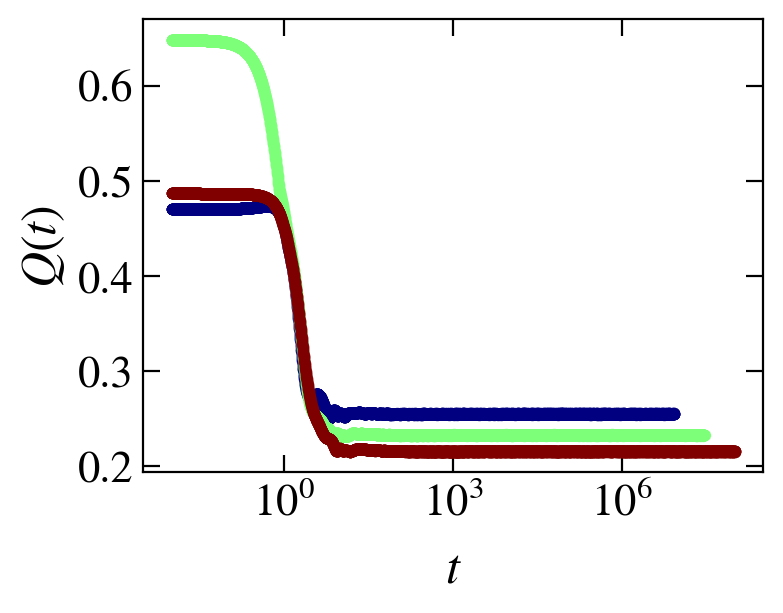

In [186]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = '../results/disorder/PBC/Spectrals_SzSz/'

sizes = np.arange(12, 17, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5

wx_vals = np.arange(0.2, 8.21, 0.2)



norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])


wx = 0.02
for iiL, L in enumerate(sizes):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            DOS = np.array(file.get('DOS'))[idx]
            
            G = 1#dim**(1-2*w) * L**2
            spec_fun = np.array(file.get('quench'))
            omegas = np.array(file.get('times')) / G
            
            realis = np.array(file.get('realisations'))
    else:
        print(name)
    
    axis.scatter(omegas, spec_fun, color=col, alpha=0.7, s=10)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$Q(t)$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='linear')

# axis.set_ylim(1e-3, 5e1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)